# Explore: Kaggle FIFA World Cup Team Dataset

**Source:** [harrachimustapha/fifa-world-cup-team-dataset](https://www.kaggle.com/datasets/harrachimustapha/fifa-world-cup-team-dataset) (CC BY 4.0)

Team-level features for each national team at each World Cup edition from **2002–2022** (training labels) plus a **2026** holdout set without outcome labels. One row = one team in one tournament. Features use only information available **before** the tournament.

**Files:** `train.csv` (labeled history), `test.csv` (2026 teams, labels missing)

**Match model:** `scripts/kaggle_team_features.py` merges selected columns onto Wikipedia matches; `Fifa_worldcup2026_TournamentPrediction.ipynb` trains a Random Forest on **2002+** enriched rows. See **§1** below for the exact field list.

**Refresh data:**

```bash
python scripts/download_kaggle_fifa_team_dataset.py
```

In [28]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "scripts")
from kaggle_team_features import (
    DIFF_SOURCE_SUFFIXES,
    IMPUTABLE_MATCH_COLUMNS,
    KAGGLE_TEAM_COLUMNS,
    KAGGLE_TO_MATCH_SUFFIX,
    MATCH_DERIVED_FEATURE_COLUMNS,
    MATCH_DIFF_FEATURE_COLUMNS,
    MATCH_KAGGLE_FEATURE_COLUMNS,
    MIN_YEAR_WITH_KAGGLE,
    TEAM_NAME_ALIASES,
    default_kaggle_dir,
    enrich_matches,
    match_model_feature_columns,
    training_matches,
)

pd.set_option("display.max_columns", 30)

DATA_DIR = Path("Data/kaggle_fifa_world_cup_team_dataset")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAIN_PATH}. Run: python scripts/download_kaggle_fifa_team_dataset.py"
    )

/Users/nigelcuschieri/Development/world-cup-predictor/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [29]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# 'version' is the World Cup edition year (e.g. 2006, 2022, 2026)
train = train.rename(columns={"version": "world_cup_year"})
test = test.rename(columns={"version": "world_cup_year"})

print(f"train: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"test:  {test.shape[0]} rows × {test.shape[1]} columns")
train.head()

train: 192 rows × 24 columns
test:  48 rows × 24 columns


,world_cup_year,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,52700000.0,57,581.0,29.2,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,777200000.0,9,746.0,27.8,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,48030000.0,42,612.0,27.1,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,858500000.0,1,827.0,27.1,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,18400000.0,26,683.0,24.7,2,1,1,0,0,0,0,0,0,0


## 1. Features used in the match model

`scripts/kaggle_team_features.py` is the **single source of truth** for which Kaggle fields feed the Random Forest. Each team-level column is joined onto matches as **home** and **away** sides; numeric columns also get a **home − away diff**. `continent` is not used directly — it becomes **`SameContinent`** (1 when both teams share a confederation).

**Excluded from modeling** (tournament outcomes — would leak): `winner`, `finalist`, `semi_finalist`, `quarter_finalist`.

**Wikipedia ↔ Kaggle name aliases:** `China` → `China PR`, `Curaçao` → `Cura?o`.

**Training window:** matches with `Year >= 2002`. **`squad_total_market_value_eur`** is missing for the 2002 edition; home/away/diff market-value columns are **median-imputed** at train time (see §5).

In [30]:
suffixes = list(KAGGLE_TO_MATCH_SUFFIX.values())
kaggle_feature_map = pd.DataFrame(
    {
        "kaggle_column": list(KAGGLE_TO_MATCH_SUFFIX.keys()),
        "home_column": [f"Home{s}" for s in suffixes],
        "away_column": [f"Away{s}" for s in suffixes],
        "diff_column": [f"Diff{s}" for s in suffixes],
    }
)

derived_feature_map = pd.DataFrame(
    [
        {
            "kaggle_column": "continent",
            "match_column": "SameContinent",
            "definition": "1 if home and away share the same confederation, else 0",
        }
    ]
)

model_cols = match_model_feature_columns()
summary = pd.Series(
    {
        "RF features (with team IDs)": len(model_cols),
        "Home/away Kaggle columns": len(MATCH_KAGGLE_FEATURE_COLUMNS),
        "Diff columns": len(MATCH_DIFF_FEATURE_COLUMNS),
        "Derived match columns": len(MATCH_DERIVED_FEATURE_COLUMNS),
        "Team ID columns": 2,
        "Kaggle team fields used": len(KAGGLE_TEAM_COLUMNS),
        "Median-imputed at train time": ", ".join(sorted(IMPUTABLE_MATCH_COLUMNS)),
        "Min training year": MIN_YEAR_WITH_KAGGLE,
    },
    name="value",
)

print("Kaggle column → match-level expansion")
display(kaggle_feature_map)
print("\nDerived from Kaggle")
display(derived_feature_map)
print("\nPipeline summary")
display(summary.to_frame())
print("\nFull list passed to RandomForestRegressor (match_model_feature_columns()):")
pd.DataFrame({"feature": model_cols})

Kaggle column → match-level expansion


,kaggle_column,home_column,away_column,diff_column
0,fifa_rank_pre_tournament,HomeFifaRank,AwayFifaRank,DiffFifaRank
1,fifa_points_pre_tournament,HomeFifaPoints,AwayFifaPoints,DiffFifaPoints
2,goals_scored_last_4y,HomeGoalsScoredLast4Y,AwayGoalsScoredLast4Y,DiffGoalsScoredLast4Y
3,goals_received_last_4y,HomeGoalsReceivedLast4Y,AwayGoalsReceivedLast4Y,DiffGoalsReceivedLast4Y
4,wins_last_4y,HomeWinsLast4Y,AwayWinsLast4Y,DiffWinsLast4Y
5,losses_last_4y,HomeLossesLast4Y,AwayLossesLast4Y,DiffLossesLast4Y
6,draws_last_4y,HomeDrawsLast4Y,AwayDrawsLast4Y,DiffDrawsLast4Y
7,is_host,HomeIsHost,AwayIsHost,DiffIsHost
8,squad_total_market_value_eur,HomeSquadMarketValueEur,AwaySquadMarketValueEur,DiffSquadMarketValueEur
9,squad_avg_age,HomeSquadAvgAge,AwaySquadAvgAge,DiffSquadAvgAge



Derived from Kaggle


,kaggle_column,match_column,definition
0,continent,SameContinent,1 if home and away share the same confederatio...



Pipeline summary


,value
RF features (with team IDs),36
Home/away Kaggle columns,22
Diff columns,11
Derived match columns,1
Team ID columns,2
Kaggle team fields used,11
Median-imputed at train time,"AwaySquadMarketValueEur, DiffSquadMarketValueE..."
Min training year,2002



Full list passed to RandomForestRegressor (match_model_feature_columns()):


,feature
0,HomeTeamEncoded
1,AwayTeamEncoded
2,HomeFifaRank
3,HomeFifaPoints
4,HomeGoalsScoredLast4Y
5,HomeGoalsReceivedLast4Y
6,HomeWinsLast4Y
7,HomeLossesLast4Y
8,HomeDrawsLast4Y
9,HomeIsHost


## 2. Schema and summary statistics

Columns in `train.csv` / `test.csv` that map to the match model (§1), plus `continent` (used only for `SameContinent`).

In [31]:
# Pre-tournament columns merged into the match model (from kaggle_team_features.py)
model_kaggle_cols = list(KAGGLE_TEAM_COLUMNS)
# continent → SameContinent at match level; shown here for EDA only
schema_cols = model_kaggle_cols + ["continent"]
label_cols = ["winner", "finalist", "semi_finalist", "quarter_finalist"]

print("Model Kaggle fields:", model_kaggle_cols)
print("Name aliases:", TEAM_NAME_ALIASES)
train[schema_cols].info()

Model Kaggle fields: ['fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'is_host', 'squad_total_market_value_eur', 'squad_avg_age', 'world_cup_titles_before']
Name aliases: {'China': 'China PR', 'Curaçao': 'Cura?o'}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   fifa_rank_pre_tournament      192 non-null    int64  
 1   fifa_points_pre_tournament    192 non-null    float64
 2   goals_scored_last_4y          192 non-null    int64  
 3   goals_received_last_4y        192 non-null    int64  
 4   wins_last_4y                  192 non-null    int64  
 5   losses_last_4y                192 non-null    int64  
 6   draws_last_4y                 192 non-null    int64  
 7   is_host                       192 

In [32]:
train[schema_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fifa_rank_pre_tournament,192.0,2.354167e+01,1.821450e+01,1.00,9.00,2.000000e+01,3.400000e+01,1.050000e+02
fifa_points_pre_tournament,192.0,9.541655e+02,3.675446e+02,285.00,670.50,8.240000e+02,1.182500e+03,1.841300e+03
goals_scored_last_4y,192.0,8.458333e+01,2.373178e+01,28.00,66.00,8.350000e+01,1.020000e+02,1.560000e+02
goals_received_last_4y,192.0,4.457292e+01,1.360801e+01,19.00,35.00,4.250000e+01,5.325000e+01,9.500000e+01
wins_last_4y,192.0,2.604688e+01,6.912534e+00,8.00,21.00,2.500000e+01,3.100000e+01,4.800000e+01
losses_last_4y,192.0,1.105208e+01,4.745612e+00,2.00,8.00,1.050000e+01,1.400000e+01,3.000000e+01
draws_last_4y,192.0,1.180208e+01,3.496055e+00,4.00,10.00,1.200000e+01,1.400000e+01,2.300000e+01
is_host,192.0,3.645833e-02,1.879177e-01,0.00,0.00,0.000000e+00,0.000000e+00,1.000000e+00
squad_total_market_value_eur,160.0,3.433053e+08,3.489032e+08,6270000.00,93857500.00,2.179400e+08,4.129750e+08,1.620000e+09
squad_avg_age,192.0,2.724964e+01,1.092351e+00,23.92,26.56,2.722500e+01,2.800000e+01,2.978000e+01


## 3. Coverage by tournament and continent

In [33]:
teams_per_edition = train.groupby("world_cup_year").size().rename("teams")
hosts = train.loc[train["is_host"] == 1, ["world_cup_year", "team"]]

display(teams_per_edition.to_frame())
print("Host nations per edition:")
display(hosts.set_index("world_cup_year"))

,teams
world_cup_year,
2002,32
2006,32
2010,32
2014,32
2018,32
2022,32


Host nations per edition:


,team
world_cup_year,
2006,Germany
2018,Russia
2022,Qatar
2010,South Africa
2014,Brazil
2002,Japan
2002,South Korea


In [34]:
continent_mix = (
    train.groupby(["world_cup_year", "continent"]).size().unstack(fill_value=0)
)
continent_mix

continent,Africa,Asia,Europe,North America,Oceania,South America
world_cup_year,,,,,,
2002,5,4,15,3,0,5
2006,5,4,14,4,1,4
2010,6,3,13,3,2,5
2014,5,3,13,4,1,6
2018,5,4,14,3,1,5
2022,5,5,13,4,1,4


## 4. Outcome labels (2002–2022 only)

Binary flags for how far each team progressed. A winner is also coded as finalist, semi-finalist, and quarter-finalist. **Not used as Random Forest inputs** (see §1).

In [35]:
label_rates = train[label_cols].mean().mul(100).round(1)
label_rates.rename("% of team-rows").to_frame()

,% of team-rows
winner,3.1
finalist,6.2
semi_finalist,12.5
quarter_finalist,25.0


In [36]:
winners = train.loc[train["winner"] == 1, ["world_cup_year", "team", "fifa_rank_pre_tournament"]]
winners.sort_values("world_cup_year")

,world_cup_year,team,fifa_rank_pre_tournament
162,2002,Brazil,2
13,2006,Italy,13
124,2010,Spain,2
142,2014,Germany,2
42,2018,France,7
64,2022,Argentina,3


## 5. Missing values and feature notes

Completeness of the **model Kaggle fields** in `train.csv`. Only market value is sparse; it is median-imputed on the match-level home/away/diff columns during training.

In [37]:
missing = train[model_kaggle_cols + ["continent"]].isna().sum()
missing[missing > 0].sort_values(ascending=False)

squad_total_market_value_eur    32
dtype: int64

In [38]:
# squad_total_market_value_eur: 0% coverage in 2002 → impute Home/Away/DiffSquadMarketValueEur
train.groupby("world_cup_year")["squad_total_market_value_eur"].apply(
    lambda s: s.notna().mean()
).mul(100).round(1).rename("% with market value")

world_cup_year
2002      0.0
2006    100.0
2010    100.0
2014    100.0
2018    100.0
2022    100.0
Name: % with market value, dtype: float64

## 6. Relationships: FIFA rank, form, and outcomes

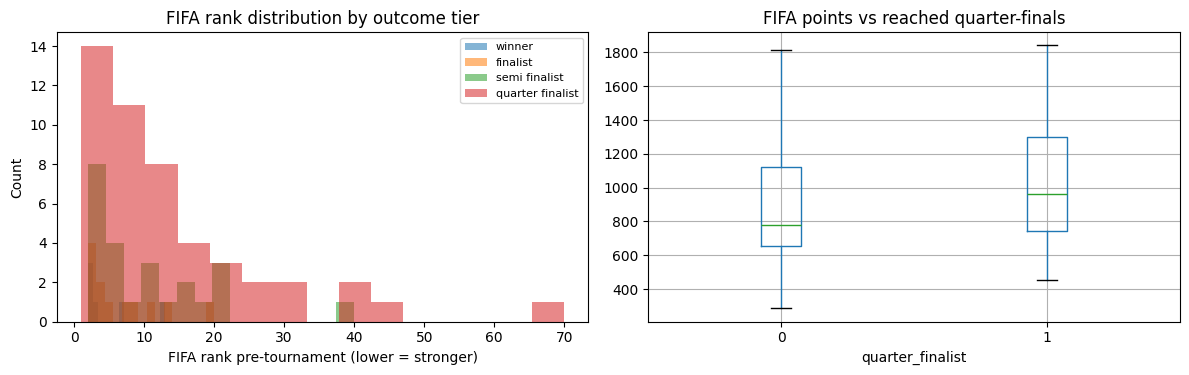

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in zip(label_cols, ["#d4a017", "#2a6ebb", "#3d9e6f", "#9b59b6"]):
    subset = train.loc[train[label] == 1, "fifa_rank_pre_tournament"]
    axes[0].hist(subset, bins=15, alpha=0.55, label=label.replace("_", " "))
axes[0].set_xlabel("FIFA rank pre-tournament (lower = stronger)")
axes[0].set_ylabel("Count")
axes[0].set_title("FIFA rank distribution by outcome tier")
axes[0].legend(fontsize=8)

train.boxplot(column="fifa_points_pre_tournament", by="quarter_finalist", ax=axes[1])
axes[1].set_title("FIFA points vs reached quarter-finals")
axes[1].set_xlabel("quarter_finalist")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [40]:
# Correlation of model Kaggle fields with quarter_finalist label (EDA only)
corr_with_qf = (
    train[model_kaggle_cols + ["quarter_finalist"]]
    .corr(numeric_only=True)["quarter_finalist"]
    .drop("quarter_finalist")
    .sort_values(key=abs, ascending=False)
)
corr_with_qf.to_frame("corr with quarter_finalist")

,corr with quarter_finalist
squad_total_market_value_eur,0.499386
world_cup_titles_before,0.372239
fifa_rank_pre_tournament,-0.307208
losses_last_4y,-0.237603
goals_scored_last_4y,0.175824
fifa_points_pre_tournament,0.167458
wins_last_4y,0.149599
goals_received_last_4y,-0.144896
is_host,0.144393
squad_avg_age,-0.021887


## 7. 2026 test set (model features only)

In [41]:
test.head(10)

,world_cup_year,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2026,France,Europe,0,85,32,25,6,7,2,1290000000,1,1877.32,26.7,16,10,8,9,7,4,NaN,NaN,NaN,NaN
1,2026,Spain,Europe,0,104,32,29,2,8,1,1150000000,2,1876.40,27.2,16,11,9,6,2,1,NaN,NaN,NaN,NaN
2,2026,Argentina,South America,0,80,14,30,4,3,3,575000000,3,1874.81,27.9,18,15,10,10,6,6,NaN,NaN,NaN,NaN
3,2026,England,Europe,0,82,23,26,6,7,1,1300000000,4,1825.97,26.8,16,13,8,10,3,1,NaN,NaN,NaN,NaN
4,2026,Portugal,Europe,0,98,31,26,5,7,0,841000000,5,1763.83,27.1,8,5,4,3,2,0,NaN,NaN,NaN,NaN
5,2026,Brazil,South America,0,58,39,15,10,10,5,932000000,6,1761.16,27.8,22,20,12,17,11,6,NaN,NaN,NaN,NaN
6,2026,Netherlands,Europe,0,92,41,21,8,9,0,808000000,7,1757.87,26.6,11,11,9,7,5,3,NaN,NaN,NaN,NaN
7,2026,Morocco,Africa,0,100,18,37,2,9,0,435550000,8,1755.87,27.4,6,2,2,1,1,0,NaN,NaN,NaN,NaN
8,2026,Belgium,Europe,0,80,32,19,7,10,0,442200000,9,1734.71,27.1,14,9,8,3,2,0,NaN,NaN,NaN,NaN
9,2026,Germany,Europe,0,80,47,21,10,7,4,828000000,10,1730.37,26.6,20,18,10,16,13,8,NaN,NaN,NaN,NaN


In [42]:
test_2026 = test.sort_values("fifa_rank_pre_tournament")[
    ["team", "continent"] + model_kaggle_cols
]
test_2026

,team,continent,fifa_rank_pre_tournament,fifa_points_pre_tournament,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,is_host,squad_total_market_value_eur,squad_avg_age,world_cup_titles_before
0,France,Europe,1,1877.32,85,32,25,6,7,0,1290000000,26.7,2
1,Spain,Europe,2,1876.40,104,32,29,2,8,0,1150000000,27.2,1
2,Argentina,South America,3,1874.81,80,14,30,4,3,0,575000000,27.9,3
3,England,Europe,4,1825.97,82,23,26,6,7,0,1300000000,26.8,1
4,Portugal,Europe,5,1763.83,98,31,26,5,7,0,841000000,27.1,0
5,Brazil,South America,6,1761.16,58,39,15,10,10,0,932000000,27.8,5
6,Netherlands,Europe,7,1757.87,92,41,21,8,9,0,808000000,26.6,0
7,Morocco,Africa,8,1755.87,100,18,37,2,9,0,435550000,27.4,0
8,Belgium,Europe,9,1734.71,80,32,19,7,10,0,442200000,27.1,0
9,Germany,Europe,10,1730.37,80,47,21,10,7,0,828000000,26.6,4


## 8. Enriched Wikipedia matches

`scripts/scrape_historical_matches.py` merges §1 features onto `Data/clean_fifa_worldcup_matches.csv` (one row per match). Training uses **2002+** rows via `training_matches()`.

In [43]:
matches_path = Path("Data/clean_fifa_worldcup_matches.csv")
if not matches_path.exists():
    print(f"Skip — {matches_path} not found (run scripts/scrape_historical_matches.py).")
else:
    matches = pd.read_csv(matches_path)
    if "SameContinent" not in matches.columns:
        matches = enrich_matches(matches, default_kaggle_dir())

    wiki_teams = set(matches["HomeTeam"]).union(matches["AwayTeam"])
    kaggle_teams = set(train["team"]).union(test["team"])
    print(f"Wikipedia match teams (all years): {len(wiki_teams)}")
    print(f"Kaggle team names:                 {len(kaggle_teams)}")
    print(f"Name aliases applied at join:      {TEAM_NAME_ALIASES}")
    print(f"Total match rows:                    {len(matches)}")
    print(f"Trainable rows (Year >= {MIN_YEAR_WITH_KAGGLE}): {len(training_matches(matches))}")
    print(f"RF feature count:                    {len(match_model_feature_columns())}")

    preview_cols = [
        "Year",
        "HomeTeam",
        "AwayTeam",
        "HomeFifaRank",
        "AwayFifaRank",
        "DiffFifaRank",
        "HomeSquadAvgAge",
        "DiffWorldCupTitlesBefore",
        "SameContinent",
    ]
    display(matches.loc[matches["Year"] >= MIN_YEAR_WITH_KAGGLE, preview_cols].head(8))

Wikipedia match teams (all years): 86
Kaggle team names:                 72
Name aliases applied at join:      {'China': 'China PR', 'Curaçao': 'Cura?o'}
Total match rows:                    964
Trainable rows (Year >= 2002): 384
RF feature count:                    36


,Year,HomeTeam,AwayTeam,HomeFifaRank,AwayFifaRank,DiffFifaRank,HomeSquadAvgAge,DiffWorldCupTitlesBefore,SameContinent
580,2002,Germany,Paraguay,11.0,18.0,-7.0,28.15,3.0,0.0
581,2002,Denmark,England,20.0,12.0,8.0,27.96,-1.0,1.0
582,2002,Sweden,Senegal,19.0,42.0,-23.0,27.22,0.0,0.0
583,2002,Spain,Republic of Ireland,8.0,15.0,-7.0,27.11,0.0,1.0
584,2002,Mexico,United States,7.0,13.0,-6.0,28.99,0.0,1.0
585,2002,Brazil,Belgium,2.0,23.0,-21.0,26.70,4.0,0.0
586,2002,Japan,Turkey,32.0,22.0,10.0,25.80,0.0,0.0
587,2002,South Korea,Italy,40.0,6.0,34.0,27.13,-3.0,0.0


## Related notebooks

- **`Fifa_worldcup2026_TournamentPrediction.ipynb`** — trains Random Forest on enriched 2002+ matches and simulates the 2026 tournament
- **`scripts/kaggle_team_features.py`** — update feature lists here; this notebook imports the same constants